#O Conceito de Largura de Banda
---
**Objetivo:** Compreender que sinais ocupam um "espaço" no espectro de frequências e aprender a calcular esse espaço usando critérios técnicos.

### O que é Banda ($B$)?
A largura de banda é a diferença entre a frequência máxima e a mínima contidas em um sinal:
$$B = f_{max} - f_{min}$$

No processamento de sinais, nem sempre essa banda é infinita ou clara. Vamos analisar três casos práticos.

## 1. O Sinal Quadrado (Banda Teórica vs. Prática)
Um sinal quadrado perfeito, na teoria, possui infinitos harmônicos. Porém, na prática, a maior parte da sua energia está concentrada nos primeiros picos.

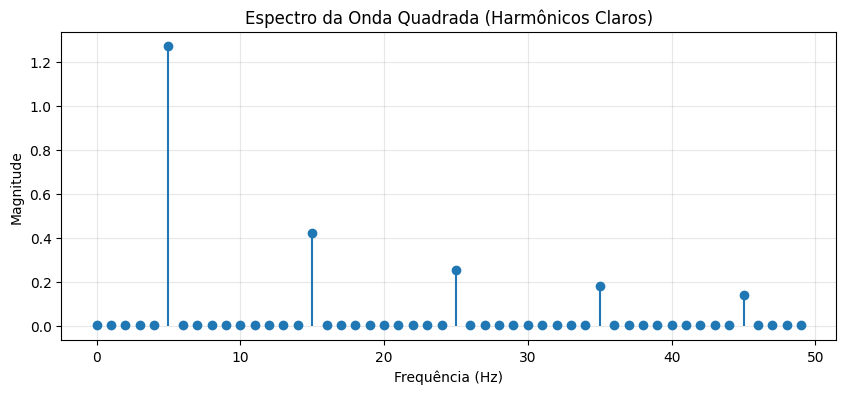

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import square
from scipy.fft import fft, fftfreq

fs = 1000 # Hz
t = np.linspace(0, 1, fs)
f_sinal = 5 # Hz (Sinal de 5Hz)

# Gerando onda quadrada
sinal_quadrado = square(2 * np.pi * f_sinal * t)

# FFT
yf = fft(sinal_quadrado)/ (len(t) / 2)
xf = fftfreq(len(t), 1/fs)

plt.figure(figsize=(10, 4))
plt.stem(xf[:50], np.abs(yf[:50]), basefmt=" ")
plt.title("Espectro da Onda Quadrada (Harmônicos Claros)")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude")
plt.grid(alpha=0.3)
plt.show()

## Exercício 1:
> **Nota Teórica:** Uma onda quadrada ideal é composta apenas por **harmônicos ímpares** ($1f, 3f, 5f...$). Por isso, você verá picos em 5 Hz, 15 Hz e 25 Hz, mas verá "zero" em 10 Hz e 20 Hz.

1. A teoria diz que a amplitude de cada harmônico $n$ de uma onda quadrada unitária é:
   $$A_n = \frac{4}{\pi \cdot n}$$
   Calcule os valores das amplitudes das harmônicos que não são zeros no gráfico.

2. Calcule a potência do 1º harmônico ($P_1 = \text{mag}^2$) e do 3º harmônico ($P_3 = \text{mag}^2$). Quantas vezes a energia da fundamental (5 Hz) é maior que a energia do terceiro harmônico (15 Hz)?

3. Se um filtro de transmissão cortasse todas as frequências acima de **10 Hz**, o sinal deixaria de ser quadrado. No código da onda quadrada, altere o limite do plot para `xf[:15]` e observe o espectro. O que restou do sinal? Ele ainda parece uma onda quadrada ou virou uma senoide pura?

## 2. Sinais com "Cauda" e a Regra dos 3dB
Muitos sinais (como um pulso sinc ou sinais reais) não terminam abruptamente no espectro. Eles possuem uma "cauda" que tende ao infinito.

**Regra dos 3dB (Banda de Meia Potência):**
Definimos a largura de banda como o intervalo onde a potência do sinal é pelo menos a metade da potência máxima.
* Em escala linear: $0.5 \times \text{Potência Máxima}$.
* Em escala de amplitude: $0.707 \times \text{Amplitude Máxima}$.
* Em escala logarítmica: **-3 dB** em relação ao pico.

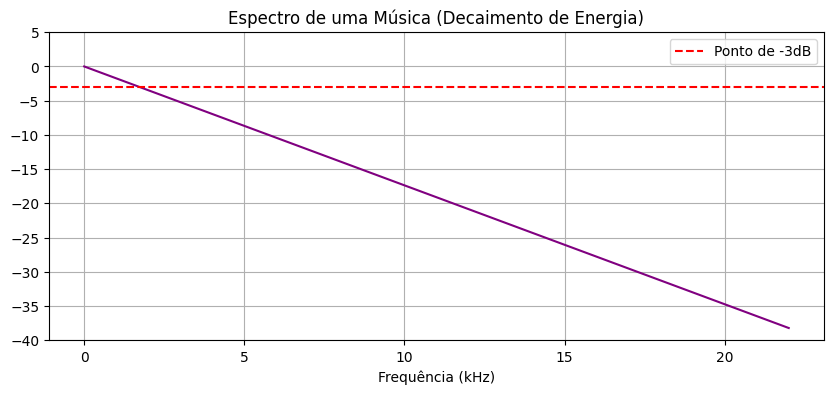

In [2]:
# Simulação de um espectro de música (ruído colorido/limitado)
freqs = np.linspace(0, 22000, 1000)
# Simulando uma queda de energia após 15kHz (comum em compressão)
espectro_musica = np.exp(-freqs/5000)

plt.figure(figsize=(10, 4))
plt.plot(freqs/1000, 20*np.log10(espectro_musica + 1e-6), color='purple')
plt.axhline(y=-3, color='r', linestyle='--', label='Ponto de -3dB')
plt.title("Espectro de uma Música (Decaimento de Energia)")
plt.xlabel("Frequência (kHz)")
ax = plt.gca()
ax.set_ylim(-40, 5)
plt.legend()
plt.grid(True)
plt.show()

## Exercício 2:

No nosso código, simulamos o espectro da música com uma função exponencial:
$$|X(f)| = e^{-f/\alpha}$$
Onde $\alpha$ é o nosso fator de decaimento (no código original, $\alpha = 5000$).

Para encontrar a frequência de corte $f_c$ onde o sinal cai **3 dB**, precisamos que a magnitude relativa seja igual a $0.707$ (ou que a potência caia pela metade).

1. Sabendo que $-3 \text{ dB} \approx 20 \cdot \log_{10}(0.707)$, encontre a $f_c$.
2. Se aumentarmos o valor de $5000$ para $15000$, a frequência de corte será maior ou menor? O que isso significa para a fidelidade do áudio?

## 3. Banda de um Sinal de Áudio (Música)
**Frequência Máxima vs. Largura de Banda**.

* **Frequência Máxima:** É o componente mais agudo que o ouvido humano ou o sistema captura (ex: 20 kHz).
* **Banda do Sinal:** É a largura total ocupada. Como o áudio começa quase em 0 Hz (graves), a banda é praticamente igual à frequência máxima.

## Exercício 3:

1. Calcule a largura de banda ($B$) e a **Taxa de Amostragem de Nyquist** ($f_s > 2 \cdot f_{max}$) para os sistemas abaixo:

| Sinal | Freq. Mínima | Freq. Máxima | Banda ($B$) | $f_s$ Mínimo (Nyquist) |
| :--- | :--- | :--- | :--- | :--- |
| **Voz (Telefonia)** | 300 Hz | 3400 Hz | ? | ? |
| **Música (Hi-Fi)** | 20 Hz | 20.000 Hz | ? | ? |
| **Vídeo (SD)** | 0 Hz | 4.200.000 Hz | ? | ? |

2. Se um canal de rádio tem apenas **10 kHz** de largura de banda disponível, qual desses sinais acima podemos transmitir sem perda de informação? Justifique usando os conceitos de filtragem e potência vistos no Exercício 1.